 # 1.02 — Do stations near subway entrances have lower availability?

 **H0:** Stations within 400m of a subway entrance and stations farther away have
 the same fill ratio.
 **H1:** Stations near a subway entrance have a LOWER fill ratio — they get
 drained harder because they sit on top of commuter foot traffic.

 The metric is `fill_ratio` (num_bikes_available / capacity) — a capacity-normalized
 level that's comparable across docks of different sizes. The two groups come
 straight from `is_within_400m`, a static proximity flag already on every row.

 Unlike 1.01 this is a TWO-sample test, not paired: the two groups are different
 physical stations (near vs far), not two measurements at the same dock. So I use
 an independent-samples t-test and a pooled-SD Cohen's d.

 Data: 2026 only — the live production data the app serves, and ~2.4M station-hours
 is already massively overpowered. (The proximity flag is static, so older years
 wouldn't change the grouping; I keep the single-era slice for consistency with the
 other 2026 hypothesis tests.)

 Authored as a `# %%` .py file (clean git diffs). Export to `.ipynb` with outputs via:
   Command Palette → "Jupyter: Export Current Python File as Jupyter Notebook"

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import psycopg2
from scipy import stats
from statsmodels.stats.power import TTestIndPower

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from citibike.config import DB_CONFIG  # noqa: E402

pd.set_option("display.max_columns", 20)

# Figures land in reports/figures — path is relative to the notebooks/ cwd
FIGURES_DIR = Path("../reports/figures")

 ## Pull the two groups — fill ratio split by subway proximity

 Both columns I need live on `training_features` directly, so this is a single-table
 pull — no namespace-bridging joins like 1.01 needed. `fill_ratio` is NULL wherever
 capacity is 0/NULL, and `is_within_400m` is NULL for the handful of stations with no
 proximity row, so I drop both. horizon_minutes = 60 keeps each station-hour to a
 single row (the other horizons are duplicate rows with different targets).

In [ ]:
conn = psycopg2.connect(**DB_CONFIG)

# Docker's /dev/shm is too small for Postgres parallel query workers — disabling
# them for this session avoids the "could not resize shared memory" DiskFull crash.
with conn.cursor() as cur:
    cur.execute("SET max_parallel_workers_per_gather = 0;")

sql = """
    SELECT
        is_within_400m,
        fill_ratio
    FROM training_features
    WHERE EXTRACT(YEAR FROM "timestamp") = 2026
      AND horizon_minutes = 60
      AND fill_ratio IS NOT NULL
      AND is_within_400m IS NOT NULL;
"""
df = pd.read_sql(sql, conn)
conn.close()
print(f"Rows loaded: {len(df):,}")
df.head()

<ipython-input-2-028426eeb600>:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


Rows loaded: 2,354,986


,is_within_400m,fill_ratio
0,False,0.631579
1,False,0.789474
2,False,0.789474
3,False,0.894737
4,False,0.947368


 ## Split into the two groups

 near = within 400m of a subway entrance, far = beyond 400m (or zero entrances
 within range). Everything from here on compares these two arrays.

In [ ]:
near = df.loc[df["is_within_400m"], "fill_ratio"]
far  = df.loc[~df["is_within_400m"], "fill_ratio"]

n_near = len(near)
n_far  = len(far)
print(f"Near subway (within 400m): n = {n_near:,}")
print(f"Far from subway:           n = {n_far:,}")

Near subway (within 400m): n = 1,401,448
Far from subway:           n = 953,538


 ## Descriptive stats

 Before any test, sanity-check the distributions. If H1 holds, the near-subway mean
 fill ratio should sit clearly below the far-from-subway mean.

In [ ]:
desc = pd.DataFrame({
    "near": near.describe(percentiles=[0.25, 0.5, 0.75]),
    "far":  far.describe(percentiles=[0.25, 0.5, 0.75]),
}).loc[["count", "mean", "std", "25%", "50%", "75%"]]
print(desc.round(4))

               near          far
count  1.401448e+06  953538.0000
mean   4.507000e-01       0.4949
std    3.168000e-01       0.3070
25%    1.667000e-01       0.2222
50%    4.286000e-01       0.5000
75%    7.368000e-01       0.7778


 ## Two-sample t-test

 The groups are independent stations of unequal size and variance, so I use Welch's
 t-test (equal_var=False) — it doesn't assume the two groups share a variance.

 H0: mean(near) − mean(far) = 0

In [ ]:
t_stat, p_value = stats.ttest_ind(near, far, equal_var=False)
mean_near = near.mean()
mean_far  = far.mean()
mean_diff = mean_near - mean_far

print(f"Mean fill ratio near:  {mean_near:.4f}")
print(f"Mean fill ratio far:   {mean_far:.4f}")
print(f"Mean difference:       {mean_diff:+.4f}")
print(f"t = {t_stat:.4f}   p = {p_value:.4e}")

Mean fill ratio near:  0.4507
Mean fill ratio far:   0.4949
Mean difference:       -0.0442
t = -107.0985   p = 0.0000e+00


 ## Effect size and 95% CI

 At this sample size the p-value is effectively zero regardless, so Cohen's d and
 the confidence interval are the numbers that matter. This is a two-sample design,
 so Cohen's d uses the POOLED standard deviation, and the CI on the difference uses
 the Welch standard error (per-group variances, not pooled).

In [ ]:
s_near, s_far = near.std(ddof=1), far.std(ddof=1)

pooled_sd = np.sqrt(
    ((n_near - 1) * s_near**2 + (n_far - 1) * s_far**2) / (n_near + n_far - 2)
)
cohens_d = mean_diff / pooled_sd

se_diff = np.sqrt(s_near**2 / n_near + s_far**2 / n_far)
ci_low  = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff

print(f"Mean difference (near − far): {mean_diff:+.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Cohen's d: {cohens_d:.4f}")

# Per-group mean CIs (for the forest plot rows)
se_near = s_near / np.sqrt(n_near)
se_far  = s_far  / np.sqrt(n_far)
near_ci = (mean_near - 1.96 * se_near, mean_near + 1.96 * se_near)
far_ci  = (mean_far  - 1.96 * se_far,  mean_far  + 1.96 * se_far)

Mean difference (near − far): -0.0442
95% CI: [-0.0450, -0.0434]
Cohen's d: -0.1413


 ## Forest plot

 This is the whole result in one picture, so I want it to read cleanly for someone
 landing on it cold on GitHub. Each row is a dot with a short horizontal bar:

 - the **dot** is the average fill ratio for that group (how full stations are, on a
   0–1 scale), and
 - the **bar** is the 95% confidence interval — the range the true average almost
   certainly sits in. The bars are tiny here because there are millions of rows, so
   the averages are pinned down very precisely.

 The top two rows are the two groups (near subway, far from subway); the near dot
 sits a little to the left, meaning emptier. The bottom row is the one that answers
 the question — the difference between the groups. The dashed line marks zero ("no
 difference"). Because the difference dot and its whole bar sit left of that line,
 near-subway stations are reliably emptier; if the bar had touched zero I couldn't
 claim a real gap.

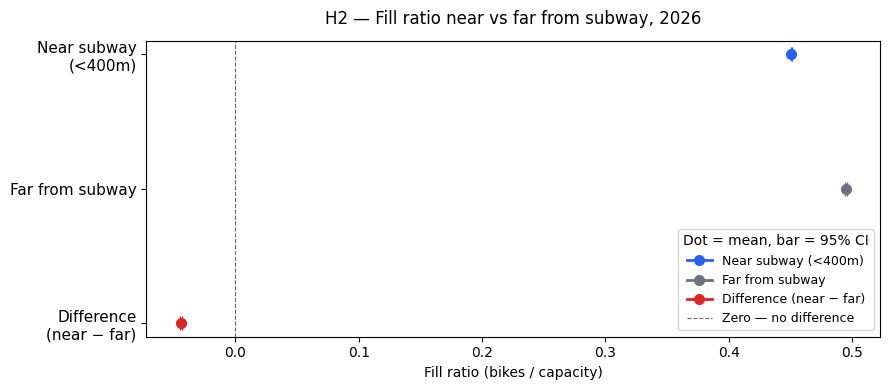

Saved -> reports/figures/1.02_forest_plot.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

rows = [
    ("Near subway\n(<400m)", mean_near, near_ci[0], near_ci[1]),
    ("Far from subway",      mean_far,  far_ci[0],  far_ci[1]),
    ("Difference\n(near − far)", mean_diff, ci_low, ci_high),
]
y_pos  = [2, 1, 0]
colors = ["#2563EB", "#6B7280", "#DC2626"]

for (label, mean, lo, hi), y, color in zip(rows, y_pos, colors):
    ax.errorbar(mean, y,
                xerr=[[mean - lo], [hi - mean]],
                fmt="o", color=color, capsize=5, markersize=7, linewidth=2)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels([r[0] for r in rows], fontsize=11)
ax.set_xlabel("Fill ratio (bikes / capacity)", fontsize=10)
ax.set_title(
    "H2 — Fill ratio near vs far from subway, 2026",
    fontsize=12, pad=12,
)

# Legend spells out what each colour is (each dot is a mean ± 95% CI) plus the
# dashed zero line, so the chart reads on its own without the y-axis labels.
legend_handles = [
    Line2D([0], [0], marker="o", color="#2563EB", linestyle="-",
           markersize=7, linewidth=2, label="Near subway (<400m)"),
    Line2D([0], [0], marker="o", color="#6B7280", linestyle="-",
           markersize=7, linewidth=2, label="Far from subway"),
    Line2D([0], [0], marker="o", color="#DC2626", linestyle="-",
           markersize=7, linewidth=2, label="Difference (near − far)"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=0.8,
           alpha=0.6, label="Zero — no difference"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9, frameon=True,
          title="Dot = mean, bar = 95% CI")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "1.02_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/1.02_forest_plot.png")

 ## Retrospective power analysis

 I want to show concretely how overpowered this test is — how many rows per group
 would have been sufficient to detect the observed effect at 80% power? This is a
 two-sample design, so I use TTestIndPower (vs the one-sample TTestPower in 1.01).
 solve_power with the actual group-size ratio returns the required size of group 1.

In [ ]:
power_analysis = TTestIndPower()
ratio = n_far / n_near
n_required = power_analysis.solve_power(
    effect_size=abs(cohens_d),
    alpha=0.05,
    power=0.80,
    ratio=ratio,
    alternative="two-sided",
)
print(f"Min rows needed in near group (80% power, α=0.05): {n_required:,.0f}")
print(f"Actual near group:                                 {n_near:,}")
print(f"Overpowered by:                                     {n_near / n_required:,.0f}×")

Min rows needed in near group (80% power, α=0.05): 972
Actual near group:                                 1,401,448
Overpowered by:                                     1,442×


 ## Conclusion

 I reject H0 — stations near a subway entrance do run emptier. Stations within 400m
 sat at a mean fill ratio of 0.451 (95% CI: 0.450–0.452) versus 0.495 for stations
 farther away, a difference of −4.42 percentage points (95% CI: −4.50 to −4.34pp,
 Cohen's d = −0.14, p < 0.0001). The direction is exactly what I expected: docks on
 top of subway entrances get drained harder by commuters spilling out, so they hold
 fewer bikes relative to their size.

 Practically, that's a station sitting about 45% full on a typical hour next to the
 subway versus closer to 50% away from it. On a 30-dock station that's only one or
 two fewer bikes — noticeable in aggregate across the network, but not something
 you'd feel walking up to any single dock.

 I want to be honest about the size, because the rate gap looks bigger than it is.
 Cohen's d is −0.14, which is a small effect. Fill ratio swings wildly hour to hour
 at any one station (std ≈ 0.31, medians 0.43 vs 0.50), so a 4-point shift in the
 mean is real and very tightly pinned down, but it's small next to that natural
 variation. With 1.4M near and 0.95M far rows the test is overpowered by ~1,400×,
 so the headline is the precision of the estimate, not the magnitude — proximity
 nudges availability down a few points, it doesn't dominate it. That fits how the
 model treats it too: subway proximity is a useful static feature, not the main
 driver of a station's state.

 **Limitations:** this is May–June 2026 only, so no winter or fall commuting
 patterns are in here. The 400m flag is a hard binary cutoff, so it can't see the
 continuous distance gradient — a station at 410m and one at 2km land in the same
 "far" bucket. A natural follow-up is to stratify by borough and confirm the gap
 holds citywide rather than being carried by Manhattan, where the subway grid is
 densest and the stations are busiest.